In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import time
import matplotlib.pyplot as plt
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [2]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root="./data", train=False, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

APPYLING RNN FROM SCRATCH

In [6]:
class VanillaRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.Wx = nn.ParameterList([
            nn.Parameter(torch.randn(input_size if i==0 else hidden_size, hidden_size)*0.01)
            for i in range(num_layers)
        ])

        self.Wh = nn.ParameterList([
            nn.Parameter(torch.randn(hidden_size, hidden_size)*0.01)
            for _ in range(num_layers)
        ])

        self.bias = nn.ParameterList([
            nn.Parameter(torch.zeros(hidden_size))
            for _ in range(num_layers)
        ])

        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        B, T, _ = x.size()
        h = [torch.zeros(B, self.hidden_size).to(device) for _ in range(self.num_layers)]

        for t in range(T):
            inp = x[:, t, :]
            for l in range(self.num_layers):
                h[l] = torch.tanh(inp @ self.Wx[l] + h[l] @ self.Wh[l] + self.bias[l])
                inp = h[l]

        return self.fc(h[-1])

APPLYING RNN USING THE BUILT - IN  MODULE.

In [7]:
class RNNModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

TRAIN FUNCITON 

In [3]:
def train(model, loader, scan_mode="row", epochs=2):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    losses = []
    grad_norms = []

    start = time.time()

    for epoch in range(epochs):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            if scan_mode == "row":
                images = images.squeeze(1)
            else:
                images = images.squeeze(1).permute(0, 2, 1)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()

            # Gradient magnitude
            total_norm = 0
            for p in model.parameters():
                if p.grad is not None:
                    total_norm += p.grad.norm().item()

            grad_norms.append(total_norm)
            optimizer.step()

            losses.append(loss.item())

    total_time = time.time() - start
    return losses, grad_norms, total_time

TEST FUNCTION

In [4]:
def test(model, loader, scan_mode="row"):
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            if scan_mode == "row":
                images = images.squeeze(1)
            else:
                images = images.squeeze(1).permute(0, 2, 1)

            outputs = model(images)
            _, pred = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (pred == labels).sum().item()

    return 100 * correct / total

RUNNING ALL THE CODE 


Running: scratch, scan=row, hidden=64, layers=1


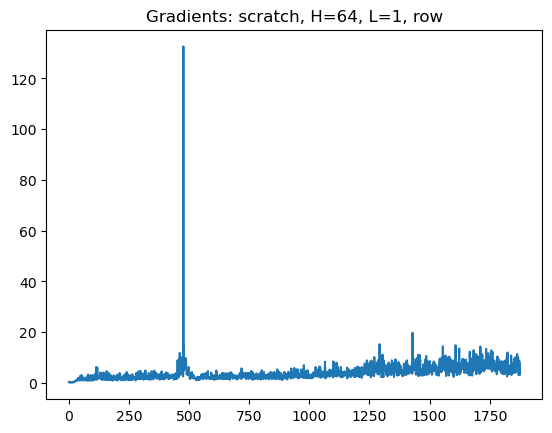


Running: scratch, scan=row, hidden=64, layers=2


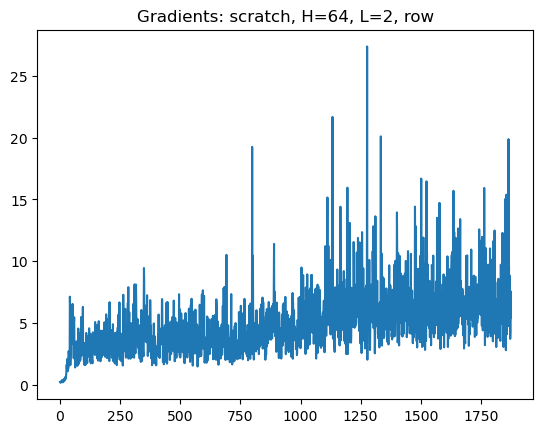


Running: scratch, scan=row, hidden=64, layers=3


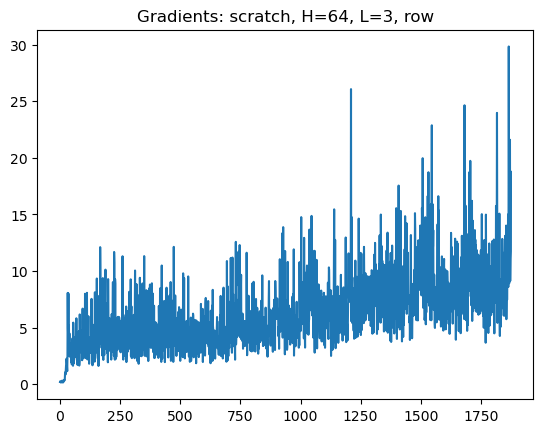


Running: scratch, scan=row, hidden=128, layers=1


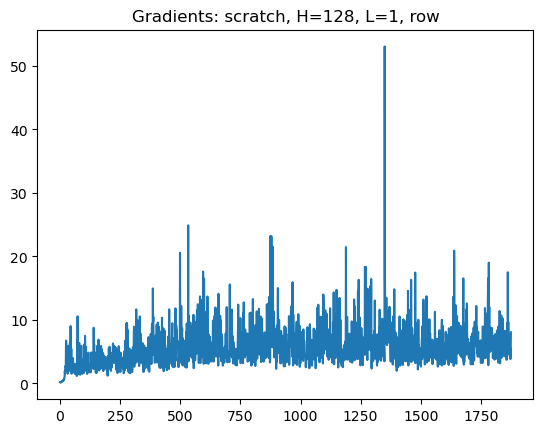


Running: scratch, scan=row, hidden=128, layers=2


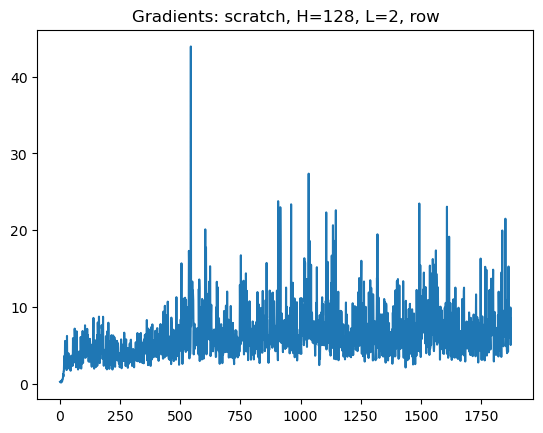


Running: scratch, scan=row, hidden=128, layers=3


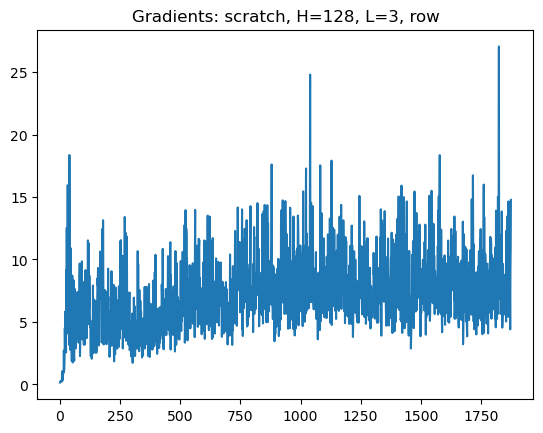


Running: scratch, scan=row, hidden=256, layers=1


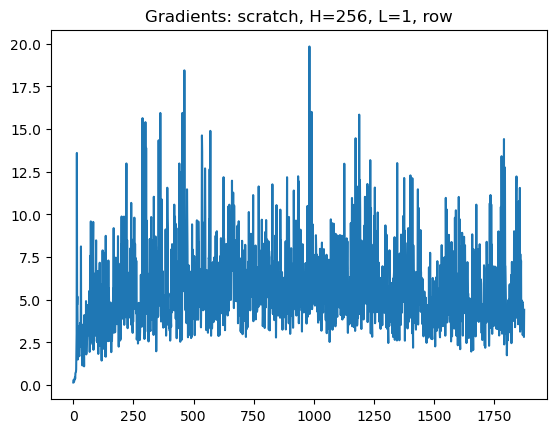


Running: scratch, scan=row, hidden=256, layers=2


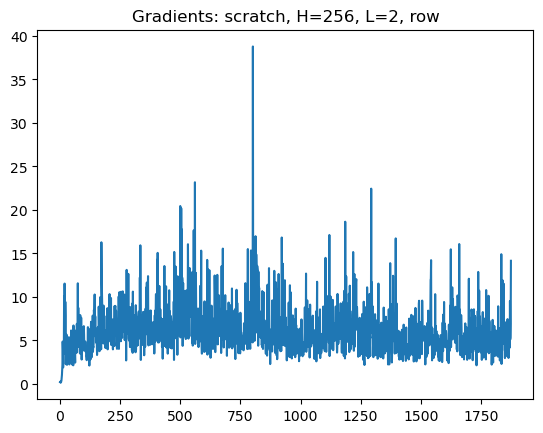


Running: scratch, scan=row, hidden=256, layers=3


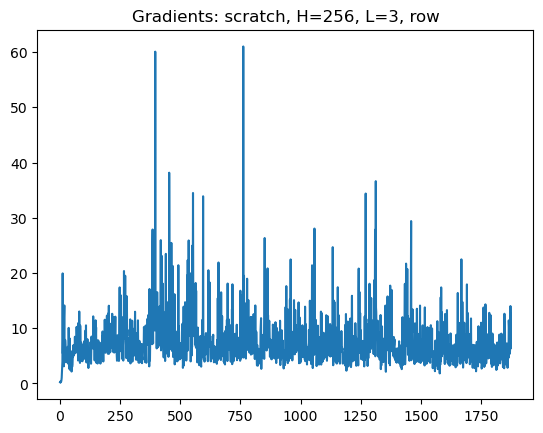


Running: scratch, scan=col, hidden=64, layers=1


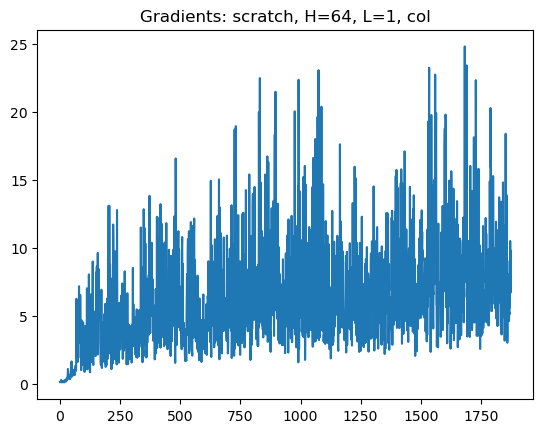


Running: scratch, scan=col, hidden=64, layers=2


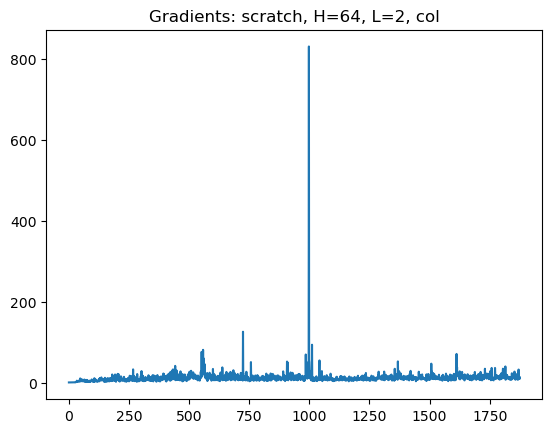


Running: scratch, scan=col, hidden=64, layers=3


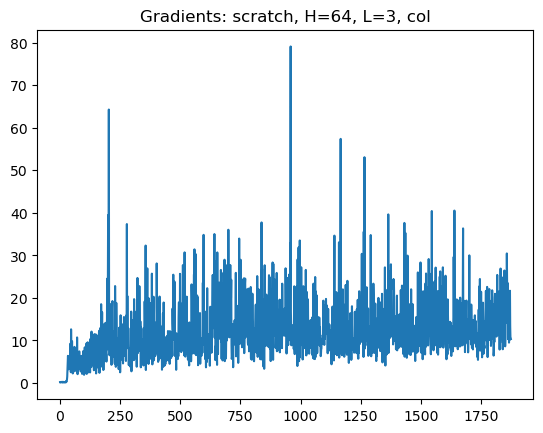


Running: scratch, scan=col, hidden=128, layers=1


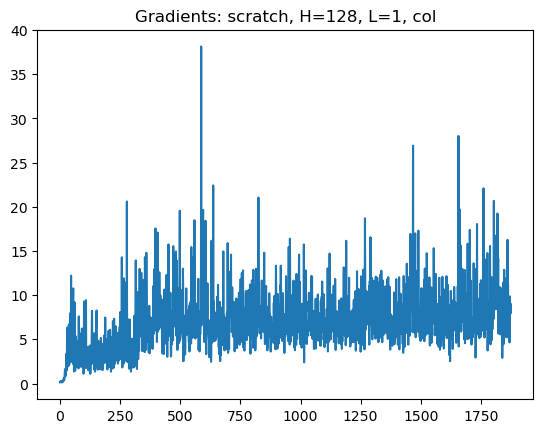


Running: scratch, scan=col, hidden=128, layers=2


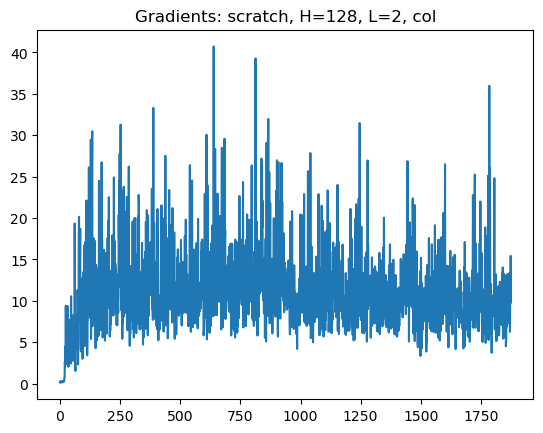


Running: scratch, scan=col, hidden=128, layers=3


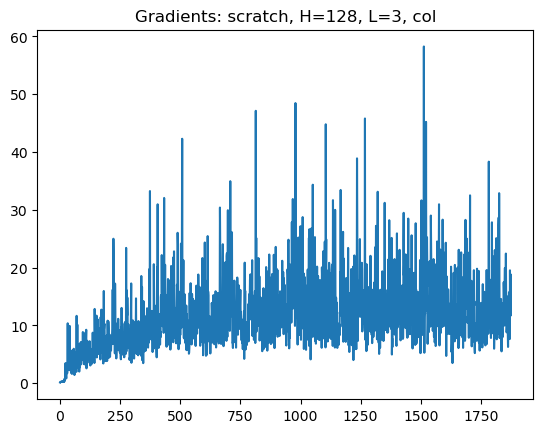


Running: scratch, scan=col, hidden=256, layers=1


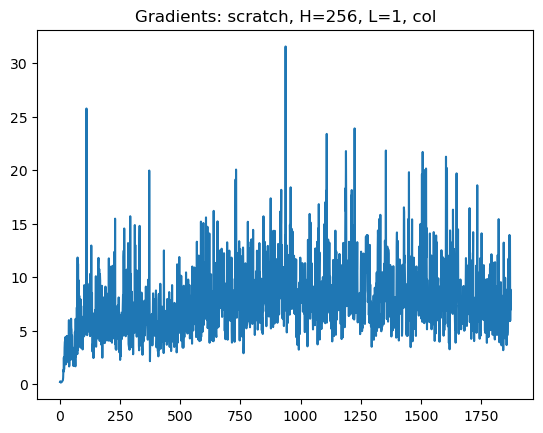


Running: scratch, scan=col, hidden=256, layers=2


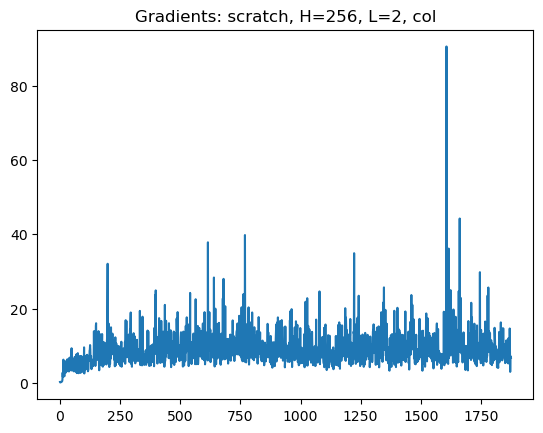


Running: scratch, scan=col, hidden=256, layers=3


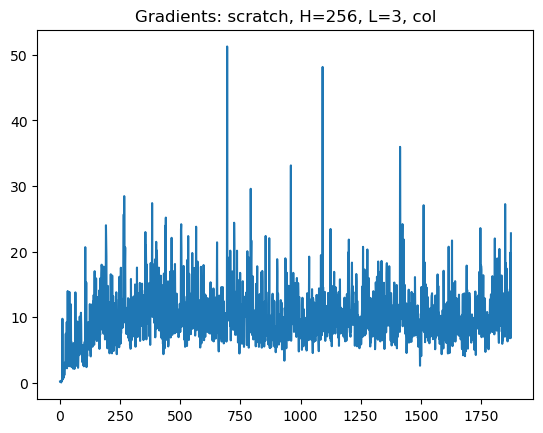


Running: builtin, scan=row, hidden=64, layers=1


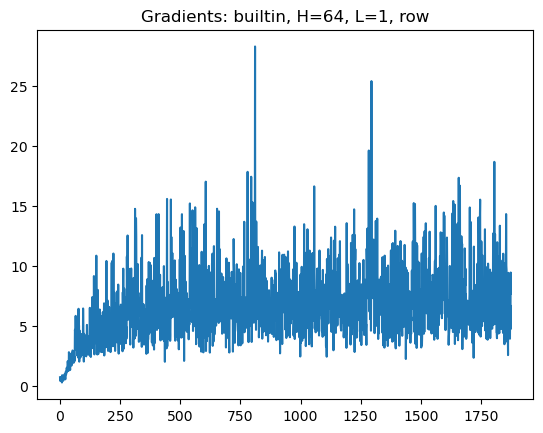


Running: builtin, scan=row, hidden=64, layers=2


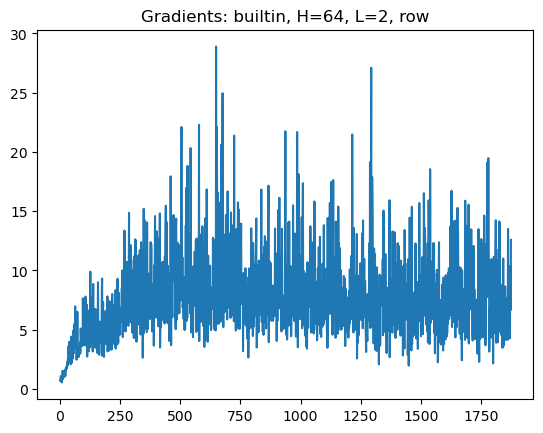


Running: builtin, scan=row, hidden=64, layers=3


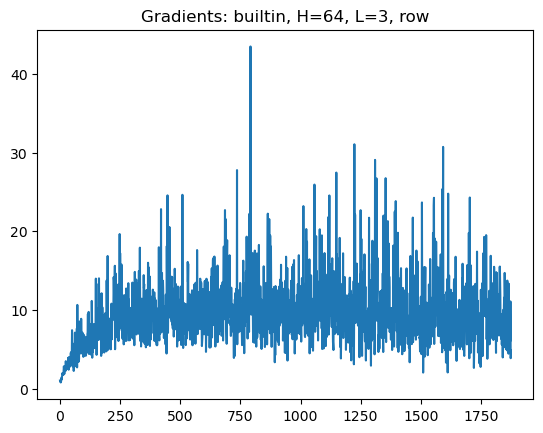


Running: builtin, scan=row, hidden=128, layers=1


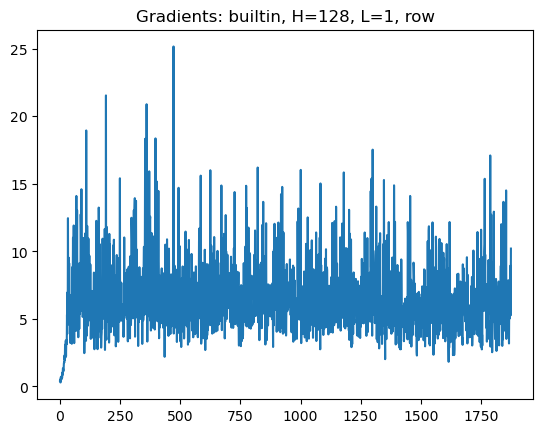


Running: builtin, scan=row, hidden=128, layers=2


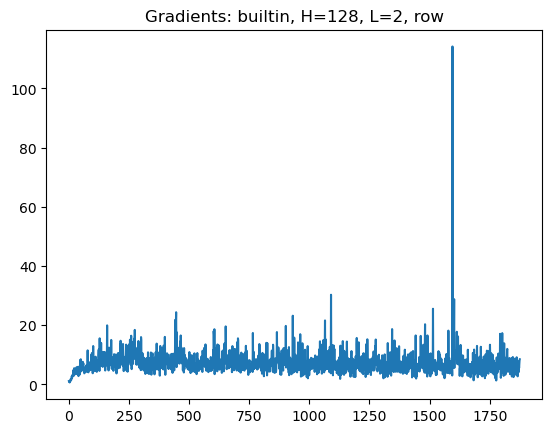


Running: builtin, scan=row, hidden=128, layers=3


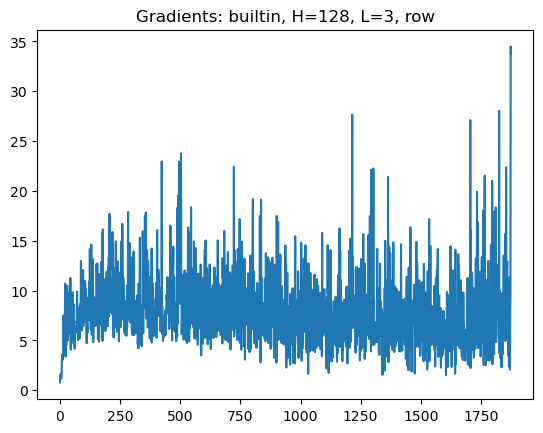


Running: builtin, scan=row, hidden=256, layers=1


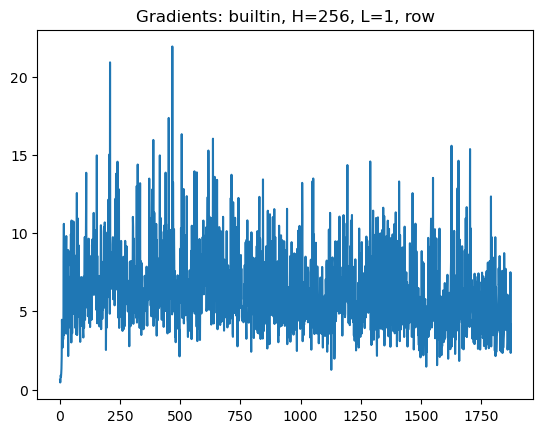


Running: builtin, scan=row, hidden=256, layers=2


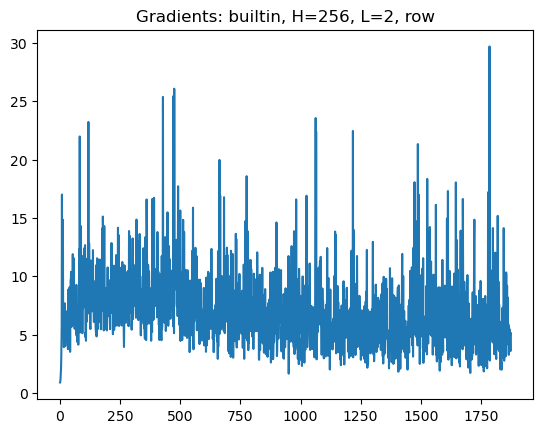


Running: builtin, scan=row, hidden=256, layers=3


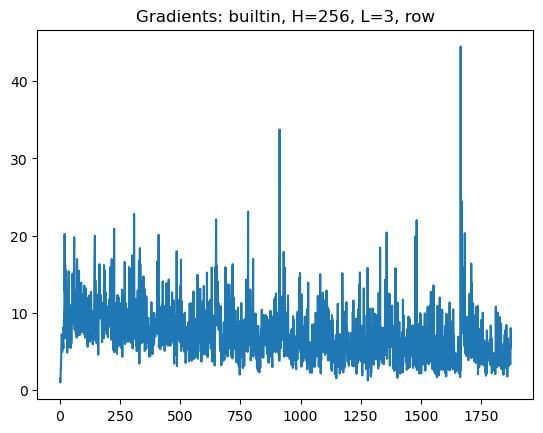


Running: builtin, scan=col, hidden=64, layers=1


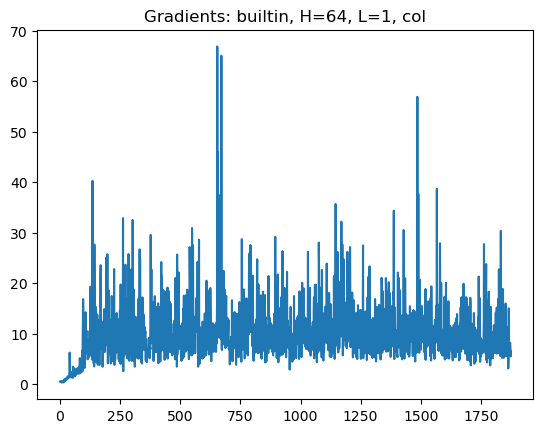


Running: builtin, scan=col, hidden=64, layers=2


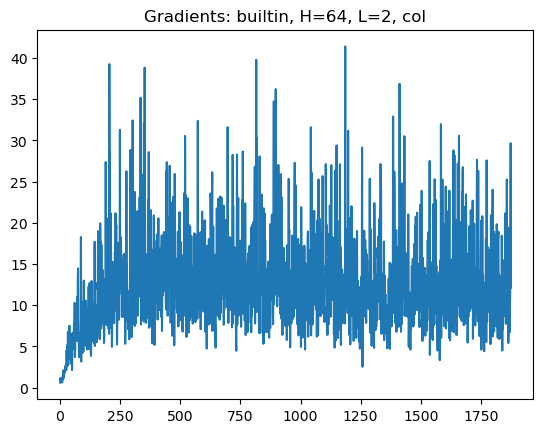


Running: builtin, scan=col, hidden=64, layers=3


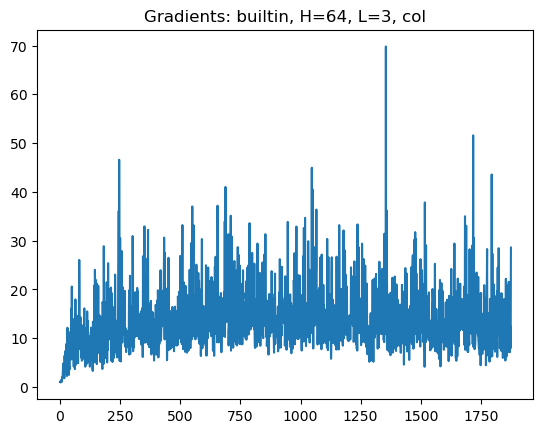


Running: builtin, scan=col, hidden=128, layers=1


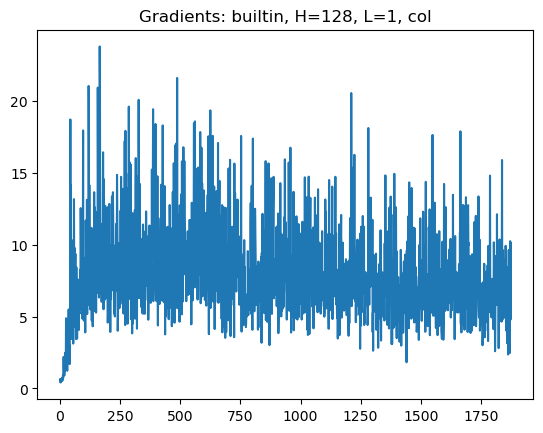


Running: builtin, scan=col, hidden=128, layers=2


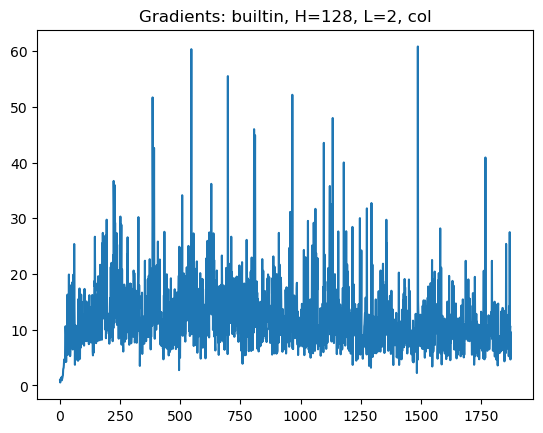


Running: builtin, scan=col, hidden=128, layers=3


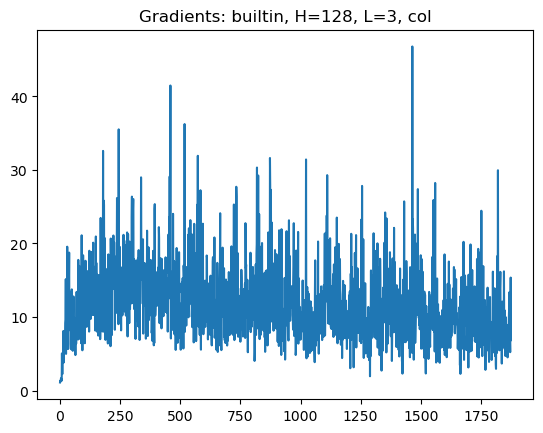


Running: builtin, scan=col, hidden=256, layers=1


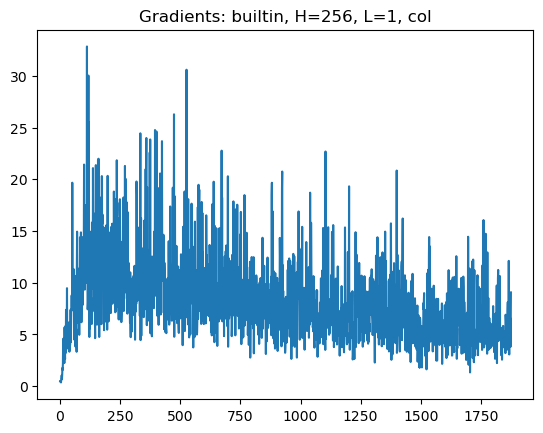


Running: builtin, scan=col, hidden=256, layers=2


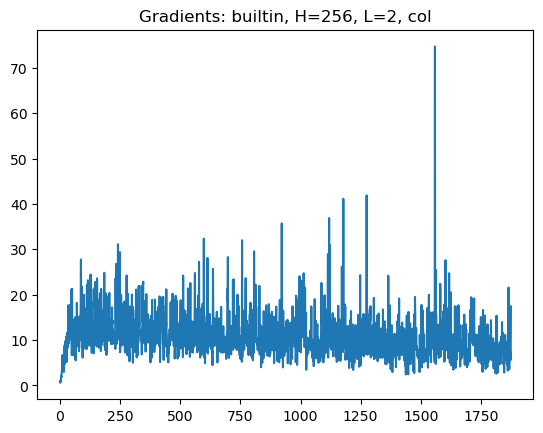


Running: builtin, scan=col, hidden=256, layers=3


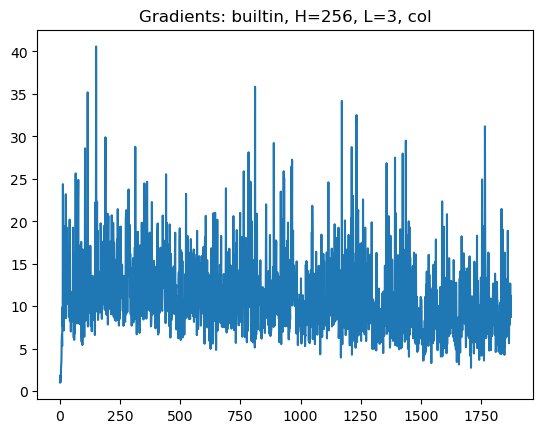

In [10]:
hidden_sizes = [64, 128, 256]
layers_list = [1, 2, 3]

results = []

for model_type in ["scratch", "builtin"]:
    for scan in ["row", "col"]:
        for hidden in hidden_sizes:
            for layers in layers_list:

                print(f"\nRunning: {model_type}, scan={scan}, hidden={hidden}, layers={layers}")

                if model_type == "scratch":
                    model = VanillaRNN(28, hidden, layers, 10).to(device)
                else:
                    model = RNNModel(28, hidden, layers, 10).to(device)

                losses, grads, t = train(model, train_loader, scan_mode=scan)
                acc = test(model, test_loader, scan_mode=scan)

                results.append({
                    "Model": model_type,
                    "Scan": scan,
                    "Hidden": hidden,
                    "Layers": layers,
                    "Accuracy": acc,
                    "Time": t,
                    "Final Loss": losses[-1]
                })

                # Plot for analysis
                plt.plot(grads)
                plt.title(f"Gradients: {model_type}, H={hidden}, L={layers}, {scan}")
                plt.show()

In [13]:
df = pd.DataFrame(results)
print(df)

df.to_csv("rnn_results.csv", index=False)

      Model Scan  Hidden  Layers  Accuracy       Time  Final Loss
0   scratch  row      64       1     74.61  41.746773    0.641655
1   scratch  row      64       2     77.29  40.279392    0.687361
2   scratch  row      64       3     73.83  85.025583    0.999808
3   scratch  row     128       1     74.47  25.940079    0.885398
4   scratch  row     128       2     85.80  39.730361    0.544366
5   scratch  row     128       3     80.65  53.661479    0.404418
6   scratch  row     256       1     91.79  27.901382    0.298799
7   scratch  row     256       2     88.32  41.763649    0.673931
8   scratch  row     256       3     86.68  57.041989    0.313466
9   scratch  col      64       1     55.17  29.025721    1.281884
10  scratch  col      64       2     65.10  51.910331    1.149456
11  scratch  col      64       3     65.66  53.085068    0.757710
12  scratch  col     128       1     74.80  27.806717    0.422502
13  scratch  col     128       2     84.55  47.243476    0.232348
14  scratc

NOTE - each model has been run for around 2 epochs we can see the highest acuracy is in built in model of the pytorch with highest accuracy of  95.96 percent
with hidden neuron or unit = 256 and layer = 3 , as it was expected 

////////////
PROBLEM STATEMENT - 2 
////////////

In [17]:
class CustomLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes, num_layers=1):
        super().__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.cells = nn.ModuleList()
        
        for i in range(num_layers):
            in_size = input_size if i == 0 else hidden_size
            self.cells.append(LSTMCellWithGates(in_size, hidden_size))
        
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        B, T, _ = x.size()
        
        h = [torch.zeros(B, self.hidden_size).to(x.device) for _ in range(self.num_layers)]
        c = [torch.zeros(B, self.hidden_size).to(x.device) for _ in range(self.num_layers)]

        for t in range(T):
            input_t = x[:, t, :]
            
            for layer in range(self.num_layers):
                h[layer], c[layer], _, _, _ = self.cells[layer](input_t, h[layer], c[layer])
                input_t = h[layer]   # pass to next layer

        return self.fc(h[-1])

In [21]:
hidden_sizes = [32, 64, 128, 256]
layers_list = [1, 2]

lstm_results = []

for num_layers in layers_list:
    for hidden_size in hidden_sizes:
        
        print(f"\nLayers = {num_layers}, Hidden = {hidden_size}")
        
        model = CustomLSTM(
            input_size=28,
            hidden_size=hidden_size,
            num_classes=10,
            num_layers=num_layers
        ).to(device)
        
        losses, grads, t = train(model, train_loader, epochs=4)
        acc = test(model, test_loader)
        
        lstm_results.append({
            "Layers": num_layers,
            "Hidden": hidden_size,
            "Accuracy": acc,
            "Time": t
        })


Layers = 1, Hidden = 32

Layers = 1, Hidden = 64

Layers = 1, Hidden = 128

Layers = 1, Hidden = 256

Layers = 2, Hidden = 32

Layers = 2, Hidden = 64

Layers = 2, Hidden = 128

Layers = 2, Hidden = 256


In [22]:
import pandas as pd
import os

df_lstm = pd.DataFrame(lstm_results)

print("\nAll Results:")
print(df_lstm)

# ✅ add model name
df_lstm["Model"] = "LSTM"

# ✅ save to master file
file_name = "master_results.csv"

if not os.path.exists(file_name):
    df_lstm.to_csv(file_name, index=False)
else:
    df_lstm.to_csv(file_name, mode='a', header=False, index=False)


All Results:
   Layers  Hidden  Accuracy        Time
0       1      32     95.70  113.740105
1       1      64     96.70  258.162631
2       1     128     97.99  280.826853
3       1     256     98.16  281.054818
4       2      32     97.23  663.154941
5       2      64     98.05  680.893364
6       2     128     97.92  628.763059
7       2     256     98.49  600.389025


In [23]:
best = df_lstm.sort_values(by="Accuracy", ascending=False).iloc[0]

print("\nBest Configuration:\n", best)

best_hidden = int(best["Hidden"])
best_layers = int(best["Layers"])


Best Configuration:
 Layers               2
Hidden             256
Accuracy         98.49
Time        600.389025
Model             LSTM
Name: 7, dtype: object


In [ ]:
class CustomLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes, num_layers=1, dropout=0.0):
        super().__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.cells = nn.ModuleList()
        
        for i in range(num_layers):
            in_size = input_size if i == 0 else hidden_size
            self.cells.append(LSTMCellWithGates(in_size, hidden_size))
        
        self.dropout = nn.Dropout(dropout)   
        
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        B, T, _ = x.size()
        
        h = [torch.zeros(B, self.hidden_size).to(x.device) for _ in range(self.num_layers)]
        c = [torch.zeros(B, self.hidden_size).to(x.device) for _ in range(self.num_layers)]

        for t in range(T):
            input_t = x[:, t, :]
            
            for layer in range(self.num_layers):
                h[layer], c[layer], _, _, _ = self.cells[layer](input_t, h[layer], c[layer])
                
                # ✅ APPLY DROPOUT BETWEEN LAYERS (not last layer)
                if layer < self.num_layers - 1:
                    h[layer] = self.dropout(h[layer])
                
                input_t = h[layer]

        return self.fc(h[-1])

In [ ]:
#6. DROPOUT EXPERIMENT (ONLY BEST CONFIG)
dropouts = [0.2, 0.3, 0.5]
dropout_results = []

best_hidden = int(best["Hidden"])
best_layers = int(best["Layers"])


if best_layers == 1:
    print("⚠️ Dropout needs >=2 layers → using 2 layers")
    best_layers = 2

for d in dropouts:
    
    print(f"\nDropout={d}")
    
    
    model = CustomLSTM(
        input_size=28,
        hidden_size=best_hidden,
        num_layers=best_layers,
        num_classes=10,
        dropout=d
    ).to(device)
    
    losses, grads, t = train(model, train_loader, epochs=2)
    acc = test(model, test_loader)
    
    dropout_results.append({
        "Dropout": d,
        "Accuracy": acc,
        "Time": t
    })


Dropout=0.2

Dropout=0.3

Dropout=0.5


In [47]:
best_layers

2

In [46]:
best_hidden

256

In [27]:
dropout_results

[{'Dropout': 0.2, 'Accuracy': 97.32, 'Time': 99.18844294548035},
 {'Dropout': 0.3, 'Accuracy': 97.17, 'Time': 362.0790491104126},
 {'Dropout': 0.5, 'Accuracy': 97.12, 'Time': 358.0580916404724}]

In [ ]:
#VISUALIZE GATE ACTIVATIONS (
#PyTorch doesn’t expose gates directly so we implement custom LSTM cell
#What visualization means:

#plotting values over time to see:
#What the model is remembering
#What it is forgetting
#When it outputs information
class LSTMCellWithGates(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.W = nn.Linear(input_size + hidden_size, 4 * hidden_size)

    def forward(self, x, h, c):
        combined = torch.cat((x, h), dim=1)
        gates = self.W(combined)

        i, f, o, g = torch.chunk(gates, 4, dim=1)

        i = torch.sigmoid(i)
        f = torch.sigmoid(f)
        o = torch.sigmoid(o)
        g = torch.tanh(g)

        c = f * c + i * g
        h = o * torch.tanh(c)

        return h, c, i, f, o

In [12]:
class StackedCustomLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super().__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # multiple LSTM cells
        self.cells = nn.ModuleList([
            LSTMCellWithGates(input_size if i==0 else hidden_size, hidden_size)
            for i in range(num_layers)
        ])
        
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        B, T, _ = x.size()
        
        h = [torch.zeros(B, self.hidden_size).to(x.device) for _ in range(self.num_layers)]
        c = [torch.zeros(B, self.hidden_size).to(x.device) for _ in range(self.num_layers)]

        for t in range(T):
            inp = x[:, t, :]
            
            for layer in range(self.num_layers):
                h[layer], c[layer], _, _, _ = self.cells[layer](inp, h[layer], c[layer])
                inp = h[layer]

        return self.fc(h[-1])

In [13]:
model_vis = StackedCustomLSTM(
    input_size=28,
    hidden_size=256,
    num_layers=2,
    num_classes=10
).to(device)
                      
losses, grads, t = train(model_vis, train_loader, epochs=4)
acc = test(model_vis, test_loader)

print("Final Accuracy:", acc)

Final Accuracy: 98.49


In [82]:
def visualize_gates_stacked(model, sample):
    model.eval()
    
    x = sample.unsqueeze(0).to(device).squeeze(1)
    
    h = [torch.zeros(1, model.hidden_size).to(device) for _ in range(model.num_layers)]
    c = [torch.zeros(1, model.hidden_size).to(device) for _ in range(model.num_layers)]

    input_gates, forget_gates, output_gates = [], [], []

    for t in range(28):
        inp = x[:, t, :]
        
        for layer in range(model.num_layers):
            h[layer], c[layer], i, f, o = model.cells[layer](inp, h[layer], c[layer])
            inp = h[layer]

            if layer == 0:  # visualize first layer
                input_gates.append(i.mean().item())
                forget_gates.append(f.mean().item())
                output_gates.append(o.mean().item())

    print("Collected:", len(input_gates))

    import matplotlib.pyplot as plt
    plt.figure(figsize=(8,5))
    plt.plot(input_gates, label="Input Gate")
    plt.plot(forget_gates, label="Forget Gate")
    plt.plot(output_gates, label="Output Gate")

    plt.legend()
    plt.title("Trained LSTM Gate Activations")

    plt.savefig("trained_gates.png")
    plt.show()

In [83]:
model_vis = StackedCustomLSTM(28, 256, 2, 10).to(device)

Collected: 28


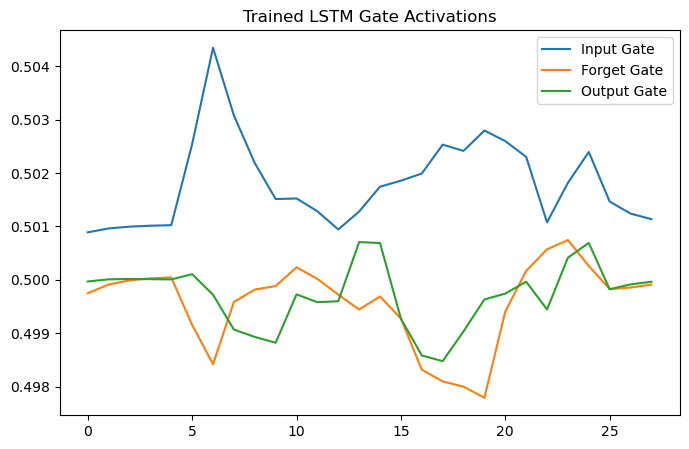

In [86]:
sample, _ = train_dataset[0]

visualize_gates_stacked(model_vis, sample)

The gate activations of the trained LSTM model show slight variations around 0.5 across time steps. This indicates that the model is moderately updating, retaining, and outputting information, but without strong gating behavior. The relatively flat nature of the curves suggests that for a simple dataset like MNIST, the LSTM does not require aggressive memory control and can perform well even with near-neutral gate activations. This demonstrates that while LSTM mitigates the vanishing gradient problem, its gating mechanisms become more prominent in complex sequence tasks.

In [68]:
df_rnn = pd.read_csv("rnn_results.csv")

comparison = {
    "Model": ["Vanilla RNN", "LSTM"],
    "Best Accuracy": [
        df_rnn["Accuracy"].max(),
        df_lstm["Accuracy"].max()
    ]
}

print(pd.DataFrame(comparison))

         Model  Best Accuracy
0  Vanilla RNN          94.95
1         LSTM          98.61


////////////
PROBLEM STATEMENT - 3
////////////

In [ ]:
import torch
import torch.nn as nn

class GRUModel(nn.Module):
    def __init__(self, input_size=28, hidden_size=128, num_layers=1, num_classes=10):
        super(GRUModel, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x shape: (batch_size, seq_len, input_size)

        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        out, _ = self.gru(x, h0)

        # Take last time step
        out = out[:, -1, :]

        out = self.fc(out)
        return out

In [29]:
gru_1 = GRUModel(num_layers=1).to(device)
gru_2 = GRUModel(num_layers=2).to(device)
gru_3 = GRUModel(num_layers=3).to(device)

In [30]:
loss1, grad1, time1 = train(gru_1, train_loader)
acc1 = test(gru_1, test_loader)

loss2, grad2, time2 = train(gru_2, train_loader)
acc2 = test(gru_2, test_loader)

loss3, grad3, time3 = train(gru_3, train_loader)
acc3 = test(gru_3, test_loader)

In [33]:
pip install thop

Note: you may need to restart the kernel to use updated packages.


In [34]:
import torch
from thop import profile
import time

def evaluate_model(model, train_loader, test_loader, device):
    model.to(device)

    # ---------------- TRAINING TIME ----------------
    start = time.time()
    train(model, train_loader)   # your existing function
    training_time = time.time() - start

    # ---------------- ACCURACY ----------------
    accuracy = test(model, test_loader)

    # ---------------- FLOPs + PARAMS ----------------
    dummy_input = torch.randn(1, 28, 28).to(device)
    flops, params = profile(model, inputs=(dummy_input,), verbose=False)

    # ---------------- MEMORY ----------------
    if torch.cuda.is_available():
        memory = torch.cuda.max_memory_allocated() / (1024**2)  # MB
    else:
        memory = 0

    # ---------------- PRINT RESULTS ----------------
    print("\n===== MODEL PERFORMANCE =====")
    print(f"Accuracy       : {accuracy:.2f}%")
    print(f"Training Time  : {training_time:.2f} sec")
    print(f"FLOPs          : {flops/1e6:.2f} MFLOPs")
    print(f"Parameters     : {params/1e6:.2f} M")
    print(f"Memory Used    : {memory:.2f} MB")
    print("=============================\n")

    return {
        "accuracy": accuracy,
        "time": training_time,
        "flops": flops,
        "params": params,
        "memory": memory
    }

In [35]:
models = {
    "GRU-1": GRUModel(num_layers=1).to(device),
    "GRU-2": GRUModel(num_layers=2).to(device),
    "GRU-3": GRUModel(num_layers=3).to(device)
}

results = {}

for name, model in models.items():
    print(f"Running {name}...")
    torch.cuda.reset_peak_memory_stats()
    results[name] = evaluate_model(model, train_loader, test_loader, device)

Running GRU-1...

===== MODEL PERFORMANCE =====
Accuracy       : 96.19%
Training Time  : 30.35 sec
FLOPs          : 1.73 MFLOPs
Parameters     : 0.06 M
Memory Used    : 63.47 MB

Running GRU-2...

===== MODEL PERFORMANCE =====
Accuracy       : 97.64%
Training Time  : 36.30 sec
FLOPs          : 4.52 MFLOPs
Parameters     : 0.16 M
Memory Used    : 64.13 MB

Running GRU-3...

===== MODEL PERFORMANCE =====
Accuracy       : 97.59%
Training Time  : 19.41 sec
FLOPs          : 7.32 MFLOPs
Parameters     : 0.26 M
Memory Used    : 72.88 MB



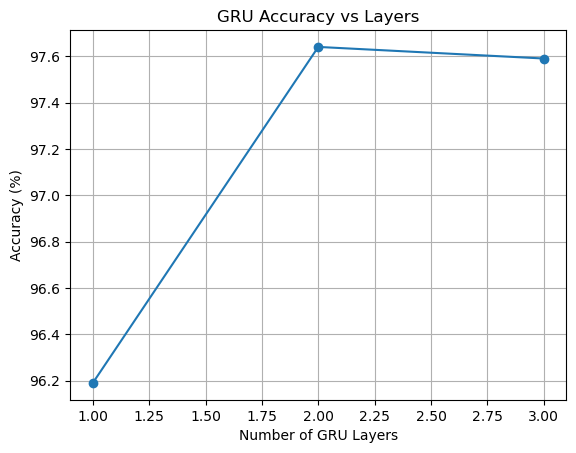

In [36]:
import matplotlib.pyplot as plt

layers = [1, 2, 3]
accuracies = [results["GRU-1"]["accuracy"],
              results["GRU-2"]["accuracy"],
              results["GRU-3"]["accuracy"]]

plt.figure()
plt.plot(layers, accuracies, marker='o')
plt.xlabel("Number of GRU Layers")
plt.ylabel("Accuracy (%)")
plt.title("GRU Accuracy vs Layers")
plt.grid()
plt.show()

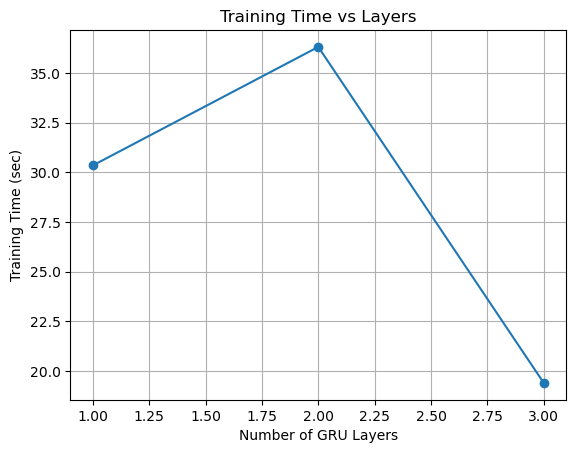

In [37]:
times = [results["GRU-1"]["time"],
         results["GRU-2"]["time"],
         results["GRU-3"]["time"]]

plt.figure()
plt.plot(layers, times, marker='o')
plt.xlabel("Number of GRU Layers")
plt.ylabel("Training Time (sec)")
plt.title("Training Time vs Layers")
plt.grid()
plt.show()

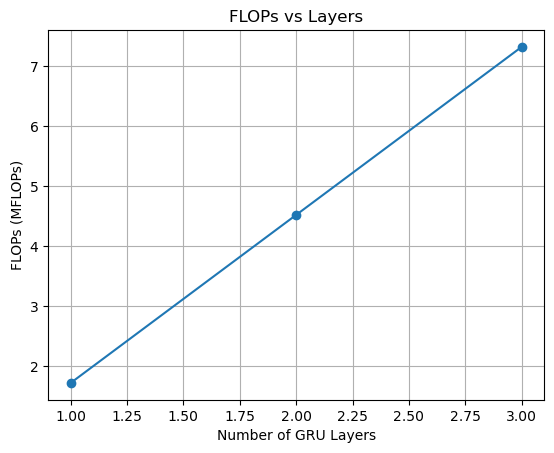

In [38]:
flops = [results["GRU-1"]["flops"]/1e6,
         results["GRU-2"]["flops"]/1e6,
         results["GRU-3"]["flops"]/1e6]

plt.figure()
plt.plot(layers, flops, marker='o')
plt.xlabel("Number of GRU Layers")
plt.ylabel("FLOPs (MFLOPs)")
plt.title("FLOPs vs Layers")
plt.grid()
plt.show()

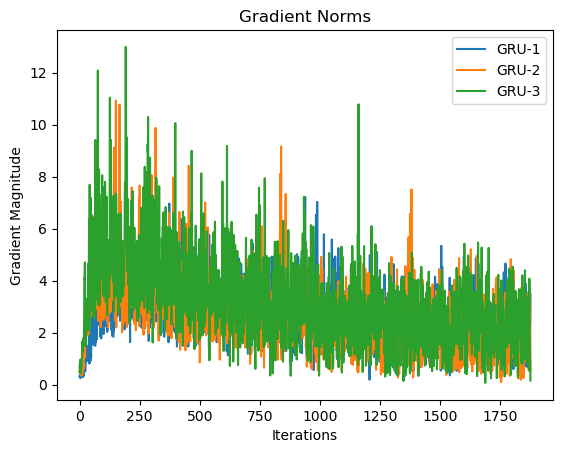

In [39]:
plt.plot(grad1, label="GRU-1")
plt.plot(grad2, label="GRU-2")
plt.plot(grad3, label="GRU-3")
plt.legend()
plt.title("Gradient Norms")
plt.xlabel("Iterations")
plt.ylabel("Gradient Magnitude")
plt.show()

When to Prefer GRU over LSTM
Dataset is small
Faster training is required
Limited computational resources
Real-time applications

Use LSTM when

Long-term dependencies are critical
Maximum accuracy is required

//////////
PROBLEM STATEMENT - 4
//////////

In [42]:
import torch
import torch.nn as nn

class BiLSTMModel(nn.Module):
    def __init__(self, input_size=28, hidden_size=128, num_layers=1, num_classes=10):
        super(BiLSTMModel, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True  
        )

        # hidden_size * 2 because of forward + backward
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_size).to(x.device)

        out, _ = self.lstm(x, (h0, c0))

        out = out[:, -1, :]   # last timestep
        out = self.fc(out)

        return out

In [43]:
class BiLSTM_Avg(nn.Module):
    def __init__(self, input_size=28, hidden_size=128, num_layers=1, num_classes=10):
        super(BiLSTM_Avg, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True
        )

        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_size).to(x.device)

        out, _ = self.lstm(x, (h0, c0))

        # split forward & backward
        forward_out = out[:, :, :self.hidden_size]
        backward_out = out[:, :, self.hidden_size:]

        out = (forward_out + backward_out) / 2
        out = out[:, -1, :]

        out = self.fc(out)
        return out

ABOVE WE HAVE 
BiLSTM implemented using both concatenation and averaging of forward and backward hidden states. Concatenation doubles feature size, while averaging reduces dimensionality.

In [44]:
class BiGRUModel(nn.Module):
    def __init__(self, input_size=28, hidden_size=128, num_layers=1, num_classes=10):
        super(BiGRUModel, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True
        )

        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_size).to(x.device)

        out, _ = self.gru(x, h0)

        out = out[:, -1, :]
        out = self.fc(out)

        return out

Row-wise scan:
Forward  top  bottom
Backward  bottom  top

BiLSTM sees both directions of structure

In [48]:
models = {
    "LSTM": CustomLSTM(28 , 256 , 10).to(device),
    "BiLSTM-Concat": BiLSTMModel().to(device),
    "BiLSTM-Avg": BiLSTM_Avg().to(device),
    "BiGRU": BiGRUModel().to(device)
}

results = {}

for name, model in models.items():
    print(f"Running {name}...")
    torch.cuda.reset_peak_memory_stats()
    results[name] = evaluate_model(model, train_loader, test_loader, device)

Running LSTM...

===== MODEL PERFORMANCE =====
Accuracy       : 96.70%
Training Time  : 97.03 sec
FLOPs          : 8.15 MFLOPs
Parameters     : 0.29 M
Memory Used    : 48.82 MB

Running BiLSTM-Concat...

===== MODEL PERFORMANCE =====
Accuracy       : 95.94%
Training Time  : 14.97 sec
FLOPs          : 4.59 MFLOPs
Parameters     : 0.16 M
Memory Used    : 92.66 MB

Running BiLSTM-Avg...

===== MODEL PERFORMANCE =====
Accuracy       : 96.75%
Training Time  : 32.58 sec
FLOPs          : 4.59 MFLOPs
Parameters     : 0.16 M
Memory Used    : 93.27 MB

Running BiGRU...

===== MODEL PERFORMANCE =====
Accuracy       : 96.28%
Training Time  : 26.34 sec
FLOPs          : 3.45 MFLOPs
Parameters     : 0.12 M
Memory Used    : 89.30 MB



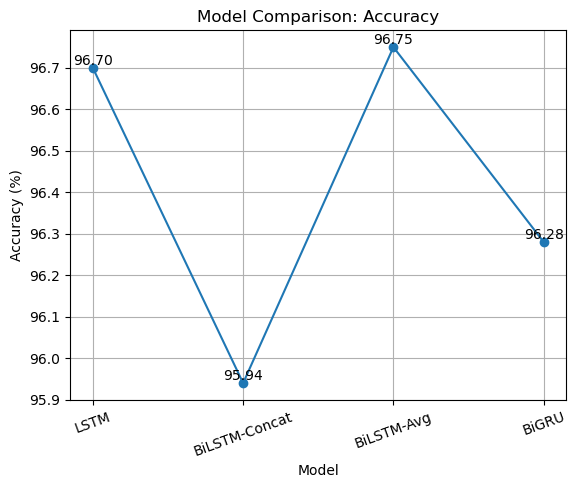

In [51]:
import matplotlib.pyplot as plt

models = ["LSTM", "BiLSTM-Concat", "BiLSTM-Avg", "BiGRU"]

accuracies = [
    results["LSTM"]["accuracy"],
    results["BiLSTM-Concat"]["accuracy"],
    results["BiLSTM-Avg"]["accuracy"],
    results["BiGRU"]["accuracy"]
]

plt.figure()
plt.plot(models, accuracies, marker='o')

# Add value labels
for x, y in zip(models, accuracies):
    plt.text(x, y, f"{y:.2f}", ha='center', va='bottom')

plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.title("Model Comparison: Accuracy")
plt.xticks(rotation=20)
plt.grid()

plt.show()

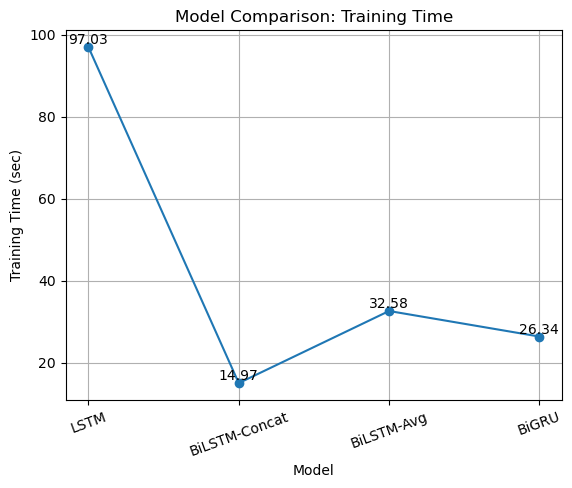

In [52]:
times = [
    results["LSTM"]["time"],
    results["BiLSTM-Concat"]["time"],
    results["BiLSTM-Avg"]["time"],
    results["BiGRU"]["time"]
]

plt.figure()
plt.plot(models, times, marker='o')

for x, y in zip(models, times):
    plt.text(x, y, f"{y:.2f}", ha='center', va='bottom')

plt.xlabel("Model")
plt.ylabel("Training Time (sec)")
plt.title("Model Comparison: Training Time")
plt.xticks(rotation=20)
plt.grid()

plt.show()

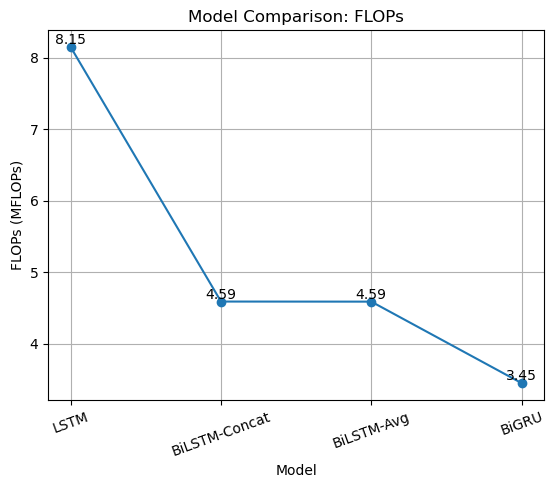

In [55]:
flops = [
    results["LSTM"]["flops"]/1e6,
    results["BiLSTM-Concat"]["flops"]/1e6,
    results["BiLSTM-Avg"]["flops"]/1e6,
    results["BiGRU"]["flops"]/1e6
]

plt.figure()
plt.plot(models, flops, marker='o')

for x, y in zip(models, flops):
    plt.text(x, y, f"{y:.2f}", ha='center', va='bottom')

plt.xlabel("Model")
plt.ylabel("FLOPs (MFLOPs)")
plt.title("Model Comparison: FLOPs")
plt.xticks(rotation=20)
plt.grid()

plt.show()

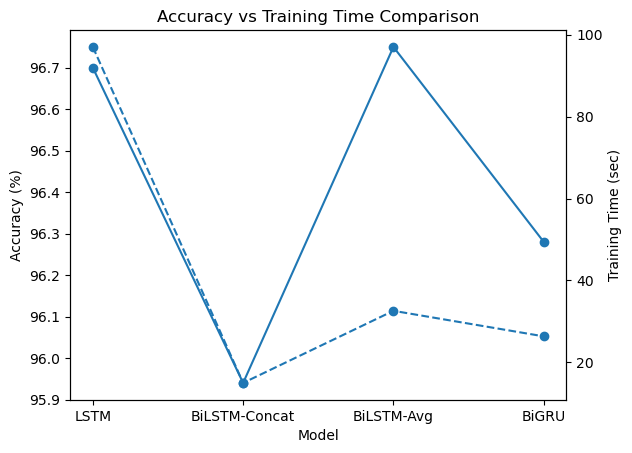

In [53]:
fig, ax1 = plt.subplots()

ax1.plot(models, accuracies, marker='o')
ax1.set_xlabel("Model")
ax1.set_ylabel("Accuracy (%)")

ax2 = ax1.twinx()
ax2.plot(models, times, linestyle='--', marker='o')
ax2.set_ylabel("Training Time (sec)")

plt.title("Accuracy vs Training Time Comparison")
plt.xticks(rotation=20)

plt.show()

//////////
PROBLEM STATEMENT - 5
//////////


In [ ]:
class CNN_LSTM(nn.Module):
    def __init__(self, hidden_size=128):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 28→14
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)    # 14→7
        )

        self.lstm = nn.LSTM(32*7, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 10)

    def forward(self, x):
        x = self.cnn(x)                  # (B,32,7,7)
        x = x.permute(0,2,1,3)           # (B,7,32,7)
        x = x.reshape(x.size(0),7,-1)    # (B,7,224)

        out, _ = self.lstm(x)
        return self.fc(out[:,-1,:])

In [68]:
class CNN_GRU(nn.Module):
    def __init__(self, hidden_size=128):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.gru = nn.GRU(32*7, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 10)

    def forward(self, x):
        x = self.cnn(x)
        x = x.permute(0,2,1,3)
        x = x.reshape(x.size(0),7,-1)

        out, _ = self.gru(x)
        return self.fc(out[:,-1,:])

In [ ]:
#first training the baseline CNN seperately because we need to alter the train fucntion for that

In [63]:
class CNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1,32,3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32,64,3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64*5*5,128),
            nn.ReLU(),
            nn.Linear(128,10)
        )
    def forward(self,x):
        return self.net(x)

In [64]:
def train_model(model, loader, mode="cnn", epochs=2):
    """
    mode:
    - "cnn" → CNN, CNN-LSTM, CNN-GRU
    - "rnn" → LSTM, GRU
    """

    import torch
    import torch.nn as nn
    import torch.optim as optim
    import time

    model.train()

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    start = time.time()

    for epoch in range(epochs):
        running_loss = 0

        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            if mode == "rnn":
                images = images.squeeze(1)   # (B,28,28)

            # cnn mode → keep (B,1,28,28)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")

    total_time = time.time() - start
    return total_time

In [65]:
def test_model(model, loader, mode="cnn"):
    import torch

    model.eval()

    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            if mode == "rnn":
                images = images.squeeze(1)

            outputs = model(images)
            _, pred = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (pred == labels).sum().item()

    return 100 * correct / total

In [66]:
from thop import profile

def evaluate_model_unified(model, train_loader, test_loader, mode="cnn"):
    model.to(device)

    torch.cuda.reset_peak_memory_stats()

    # Train
    train_time = train_model(model, train_loader, mode=mode)

    # Accuracy
    accuracy = test_model(model, test_loader, mode=mode)

    # FLOPs
    if mode == "cnn":
        dummy = torch.randn(1, 1, 28, 28).to(device)
    else:
        dummy = torch.randn(1, 28, 28).to(device)

    flops, params = profile(model, inputs=(dummy,), verbose=False)

    # Memory
    memory = torch.cuda.max_memory_allocated() / (1024**2) if torch.cuda.is_available() else 0

    print("\n===== RESULTS =====")
    print(f"Accuracy       : {accuracy:.2f}%")
    print(f"Training Time  : {train_time:.2f} sec")
    print(f"FLOPs          : {flops/1e6:.2f} MFLOPs")
    print(f"Parameters     : {params/1e6:.2f} M")
    print(f"Memory Used    : {memory:.2f} MB")
    print("====================\n")

    return {
        "accuracy": accuracy,
        "time": train_time,
        "flops": flops,
        "params": params,
        "memory": memory
    }

In [69]:
models = {
    "CNN": CNNModel().to(device),
    "LSTM": CustomLSTM(28 , 256 , 10).to(device),
    "CNN-LSTM": CNN_LSTM().to(device),
    "CNN-GRU": CNN_GRU().to(device)
}

results = {}

for name, model in models.items():
    print(f"Running {name}...")
    mode = "cnn" if "CNN" in name else "rnn"
    results[name] = evaluate_model_unified(
        model, train_loader, test_loader, mode=mode
    )

Running CNN...
Epoch 1, Loss: 173.9188
Epoch 2, Loss: 48.5059

===== RESULTS =====
Accuracy       : 98.58%
Training Time  : 18.17 sec
FLOPs          : 2.63 MFLOPs
Parameters     : 0.23 M
Memory Used    : 52.29 MB

Running LSTM...
Epoch 1, Loss: 436.6124
Epoch 2, Loss: 118.1433

===== RESULTS =====
Accuracy       : 95.71%
Training Time  : 45.97 sec
FLOPs          : 8.15 MFLOPs
Parameters     : 0.29 M
Memory Used    : 51.71 MB

Running CNN-LSTM...
Epoch 1, Loss: 289.6061
Epoch 2, Loss: 60.0183

===== RESULTS =====
Accuracy       : 98.49%
Training Time  : 18.41 sec
FLOPs          : 2.29 MFLOPs
Parameters     : 0.19 M
Memory Used    : 62.41 MB

Running CNN-GRU...
Epoch 1, Loss: 286.3789
Epoch 2, Loss: 52.4471

===== RESULTS =====
Accuracy       : 98.71%
Training Time  : 13.82 sec
FLOPs          : 1.98 MFLOPs
Parameters     : 0.14 M
Memory Used    : 62.17 MB



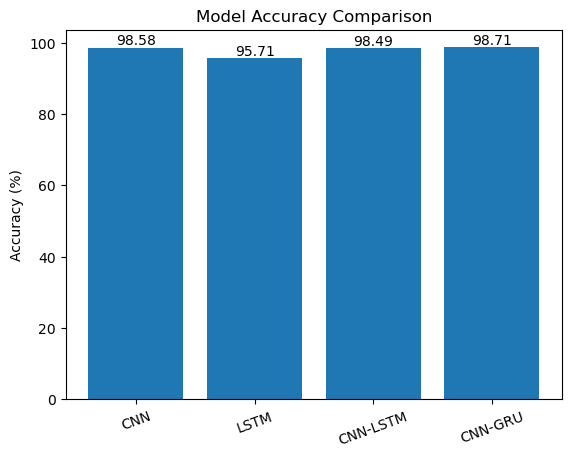

In [70]:
import matplotlib.pyplot as plt

models = list(results.keys())
accuracy = [results[m]["accuracy"] for m in models]

plt.figure()
plt.bar(models, accuracy)

for i, v in enumerate(accuracy):
    plt.text(i, v, f"{v:.2f}", ha='center', va='bottom')

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=20)
plt.show()

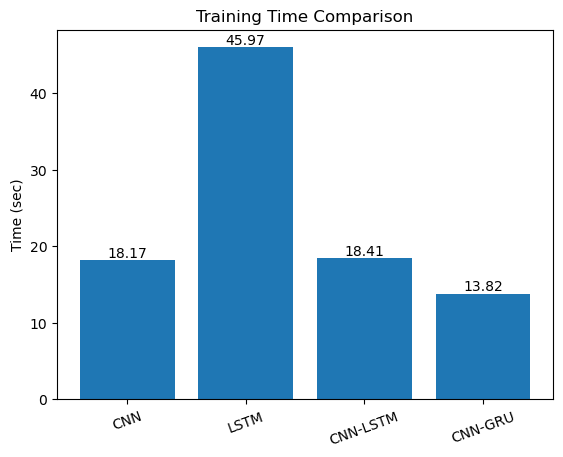

In [71]:
times = [results[m]["time"] for m in models]

plt.figure()
plt.bar(models, times)

for i, v in enumerate(times):
    plt.text(i, v, f"{v:.2f}", ha='center', va='bottom')

plt.title("Training Time Comparison")
plt.ylabel("Time (sec)")
plt.xticks(rotation=20)
plt.show()

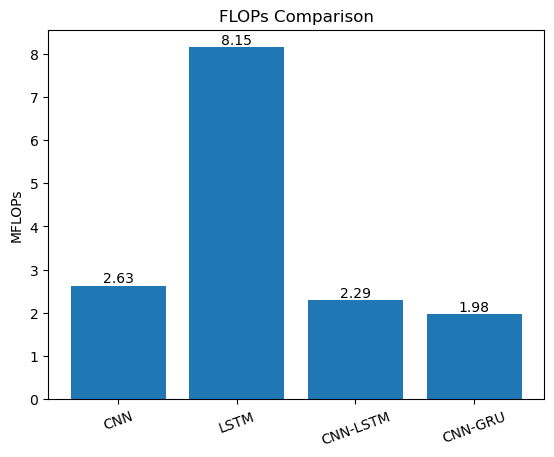

In [72]:
flops = [results[m]["flops"]/1e6 for m in models]

plt.figure()
plt.bar(models, flops)

for i, v in enumerate(flops):
    plt.text(i, v, f"{v:.2f}", ha='center', va='bottom')

plt.title("FLOPs Comparison")
plt.ylabel("MFLOPs")
plt.xticks(rotation=20)
plt.show()

///////////
PROBLEM STATMENT - 6
///////////

In [73]:
class CNN_GRU(nn.Module):
    def __init__(self, hidden_size=128, num_layers=1, dropout=0.0):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.gru = nn.GRU(
            input_size=32*7,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.fc = nn.Linear(hidden_size, 10)

    def forward(self, x):
        x = self.cnn(x)
        x = x.permute(0, 2, 1, 3)
        x = x.reshape(x.size(0), 7, -1)

        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])

In [77]:
base_config = {
    "hidden_size": 128,
    "num_layers": 1,
    "dropout": 0.0,
    "lr": 0.001
}

In [ ]:
def train_model_hp(model, loader, lr=0.001, epochs=2, clip=None):
    import torch.optim as optim

    model.train()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    import time
    start = time.time()

    for epoch in range(epochs):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()

            if clip:
                torch.nn.utils.clip_grad_norm_(model.parameters(), clip)

            optimizer.step()

    return time.time() - start

In [79]:
def test_model_hp(model, loader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, pred = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (pred == labels).sum().item()

    return 100 * correct / total

In [80]:
def run_experiment(param_name, values, base_config):
    results = {}

    for val in values:
        config = base_config.copy()
        config[param_name] = val

        print(f"\nTesting {param_name} = {val}")

        model = CNN_GRU(
            hidden_size=config["hidden_size"],
            num_layers=config["num_layers"],
            dropout=config["dropout"]
        ).to(device)

        train_model_hp(model, train_loader, lr=config["lr"])
        acc = test_model_hp(model, test_loader)

        results[val] = acc

    return results

////TUNING LEARNING RATE////

In [ ]:
lr_values = [0.1, 0.01, 0.001, 0.0001]

lr_results = run_experiment("lr", lr_values, base_config)


Testing lr = 0.1

Testing lr = 0.01

Testing lr = 0.001

Testing lr = 0.0001


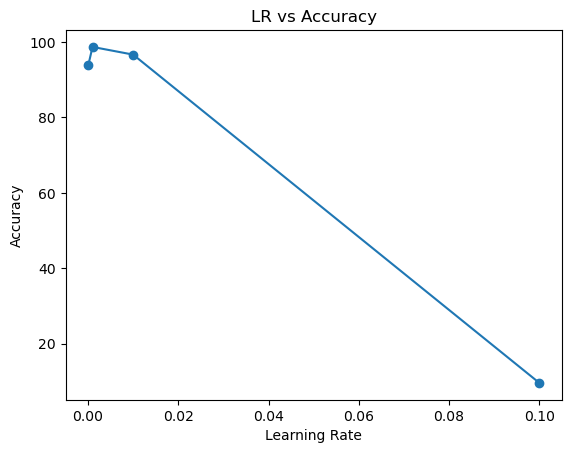

Best LR: 0.001


In [84]:
plt.plot(lr_results.keys(), lr_results.values(), marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Accuracy")
plt.title("LR vs Accuracy")
plt.show()

best_lr = max(lr_results, key=lr_results.get)
base_config["lr"] = best_lr

print("Best LR:", best_lr)

////TUNING HIDDEN - SIZE////


Testing hidden_size = 32

Testing hidden_size = 64

Testing hidden_size = 128

Testing hidden_size = 256


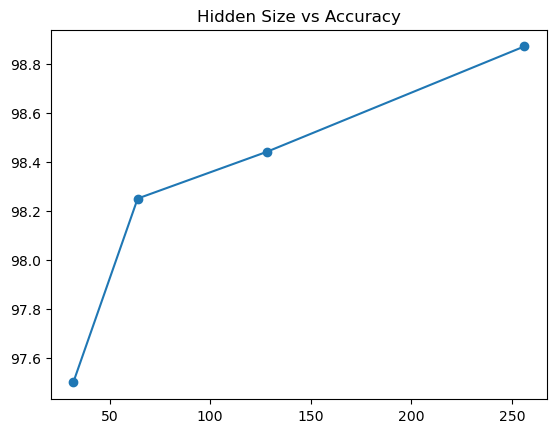

In [85]:
hidden_values = [32, 64, 128, 256]

hidden_results = run_experiment("hidden_size", hidden_values, base_config)

plt.plot(hidden_results.keys(), hidden_results.values(), marker='o')
plt.title("Hidden Size vs Accuracy")
plt.show()

best_hidden = max(hidden_results, key=hidden_results.get)
base_config["hidden_size"] = best_hidden

////TUNING LAYERS////


Testing num_layers = 1

Testing num_layers = 2

Testing num_layers = 3


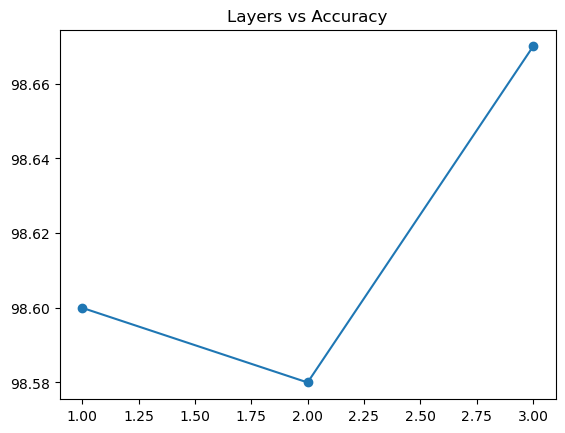

In [86]:
layer_values = [1, 2, 3]

layer_results = run_experiment("num_layers", layer_values, base_config)

plt.plot(layer_results.keys(), layer_results.values(), marker='o')
plt.title("Layers vs Accuracy")
plt.show()

best_layer = max(layer_results, key=layer_results.get)
base_config["num_layers"] = best_layer

////TUNING DROPOUT////


Testing dropout = 0.0

Testing dropout = 0.2

Testing dropout = 0.3

Testing dropout = 0.5


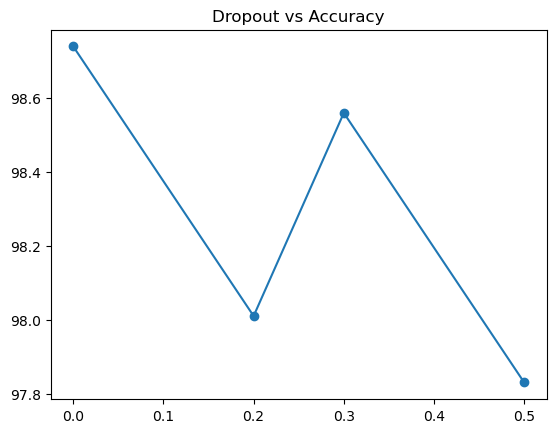

In [87]:
dropout_values = [0.0, 0.2, 0.3, 0.5]

dropout_results = run_experiment("dropout", dropout_values, base_config)

plt.plot(dropout_results.keys(), dropout_results.values(), marker='o')
plt.title("Dropout vs Accuracy")
plt.show()

best_dropout = max(dropout_results, key=dropout_results.get)
base_config["dropout"] = best_dropout

////TUNING BATCH-SIZE////

In [95]:
def train_model(model, loader, lr=0.001, epochs=2, clip=None):
    model.train()

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        running_loss = 0

        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()

            if clip:
                torch.nn.utils.clip_grad_norm_(model.parameters(), clip)

            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")


Batch Size = 32
Epoch 1, Loss: 428.3068
Epoch 2, Loss: 109.0119
Accuracy: 97.99%

Batch Size = 64
Epoch 1, Loss: 255.4759
Epoch 2, Loss: 56.8831
Accuracy: 98.50%

Batch Size = 128
Epoch 1, Loss: 170.1798
Epoch 2, Loss: 31.8623
Accuracy: 98.37%


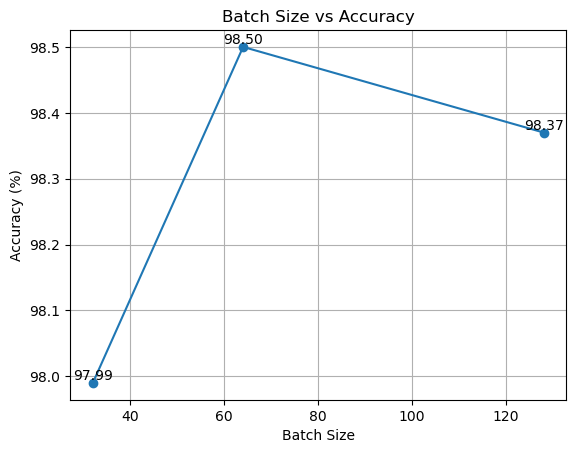


Best Batch Size: 64


In [ ]:
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

batch_sizes = [32, 64, 128]
batch_results = {}

for bs in batch_sizes:
    print(f"\nBatch Size = {bs}")

    # Create loaders
    train_loader_bs = DataLoader(train_dataset, batch_size=bs, shuffle=True)
    test_loader_bs = DataLoader(test_dataset, batch_size=bs)

  
    model = CNN_GRU(
        hidden_size=base_config["hidden_size"],
        num_layers=base_config["num_layers"],
        dropout=base_config["dropout"]
    ).to(device)

    # Train
    train_model(model, train_loader_bs, lr=base_config["lr"])

    # Test
    acc = test_model(model, test_loader_bs)
    print(f"Accuracy: {acc:.2f}%")

    batch_results[bs] = acc


plt.figure()
plt.plot(list(batch_results.keys()), list(batch_results.values()), marker='o')

# Add labels on points (important for report)
for x, y in batch_results.items():
    plt.text(x, y, f"{y:.2f}", ha='center', va='bottom')

plt.xlabel("Batch Size")
plt.ylabel("Accuracy (%)")
plt.title("Batch Size vs Accuracy")
plt.grid()
plt.show()


best_bs = max(batch_results, key=batch_results.get)
print("\nBest Batch Size:", best_bs)


base_config["batch_size"] = best_bs

In [97]:
print("Final Best Config:", base_config)

Final Best Config: {'hidden_size': 256, 'num_layers': 3, 'dropout': 0.0, 'lr': 0.001, 'batch_size': 64}


//////FINAL BEST MODEL ACCORDING TO HYPERPARAMETER TUNING//////

In [98]:
final_model = CNN_GRU(
    hidden_size=base_config["hidden_size"],
    num_layers=base_config["num_layers"],
    dropout=base_config["dropout"]
).to(device)

In [99]:
final_train_loader = DataLoader(
    train_dataset,
    batch_size=base_config["batch_size"],
    shuffle=True
)

final_test_loader = DataLoader(
    test_dataset,
    batch_size=base_config["batch_size"]
)

In [100]:
train_model(
    final_model,
    final_train_loader,
    lr=base_config["lr"],
    epochs=5   # increase for final run
)

Epoch 1, Loss: 278.6688
Epoch 2, Loss: 58.3694
Epoch 3, Loss: 41.1069
Epoch 4, Loss: 32.7723
Epoch 5, Loss: 25.8714


In [101]:
final_acc = test_model(final_model, final_test_loader)
print("\nFINAL MODEL ACCURACY:", final_acc)


FINAL MODEL ACCURACY: 99.0


/////////PROBLEM STATMENT - 7//////////

In [102]:
import pandas as pd

df = pd.DataFrame(results).T
print(df)

          accuracy       time      flops    params     memory
CNN          98.58  18.168728  2631040.0  225034.0  52.294434
LSTM         95.71  45.973239  8145408.0  294410.0  51.709961
CNN-LSTM     98.49  18.409780  2293248.0  187338.0  62.408691
CNN-GRU      98.71  13.816643  1975168.0  142026.0  62.168945


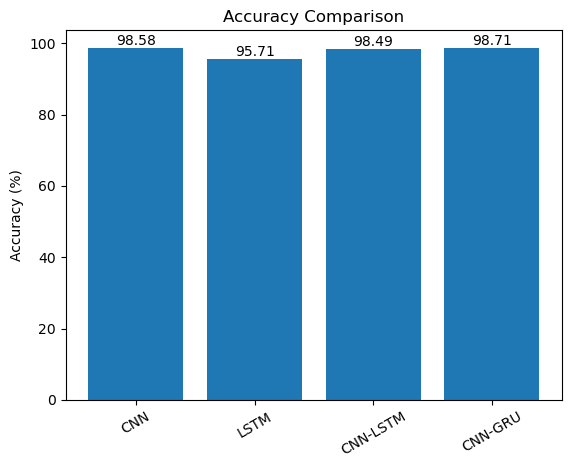

In [103]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(df.index, df["accuracy"])

for i, v in enumerate(df["accuracy"]):
    plt.text(i, v, f"{v:.2f}", ha='center', va='bottom')

plt.title("Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=30)
plt.show()

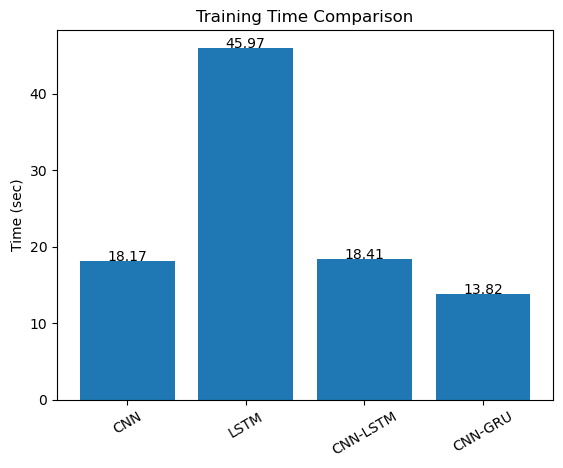

In [104]:
plt.figure()
plt.bar(df.index, df["time"])

for i, v in enumerate(df["time"]):
    plt.text(i, v, f"{v:.2f}", ha='center')

plt.title("Training Time Comparison")
plt.ylabel("Time (sec)")
plt.xticks(rotation=30)
plt.show()

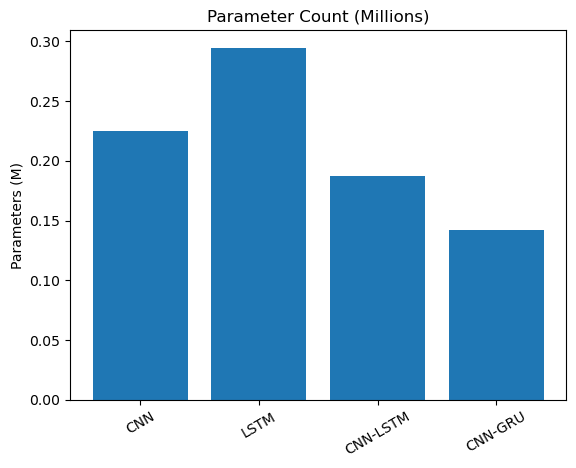

In [105]:
plt.figure()
plt.bar(df.index, df["params"]/1e6)

plt.title("Parameter Count (Millions)")
plt.ylabel("Parameters (M)")
plt.xticks(rotation=30)
plt.show()

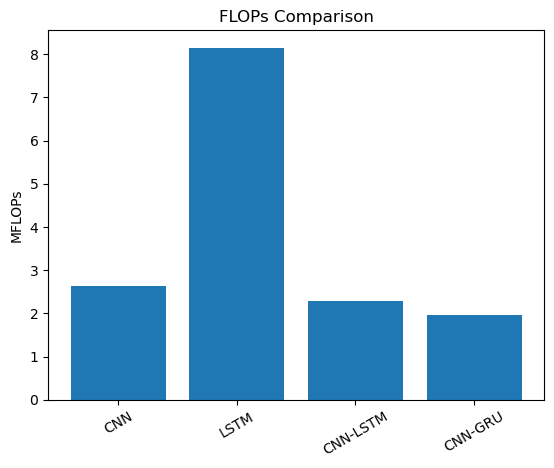

In [106]:
plt.figure()
plt.bar(df.index, df["flops"]/1e6)

plt.title("FLOPs Comparison")
plt.ylabel("MFLOPs")
plt.xticks(rotation=30)
plt.show()

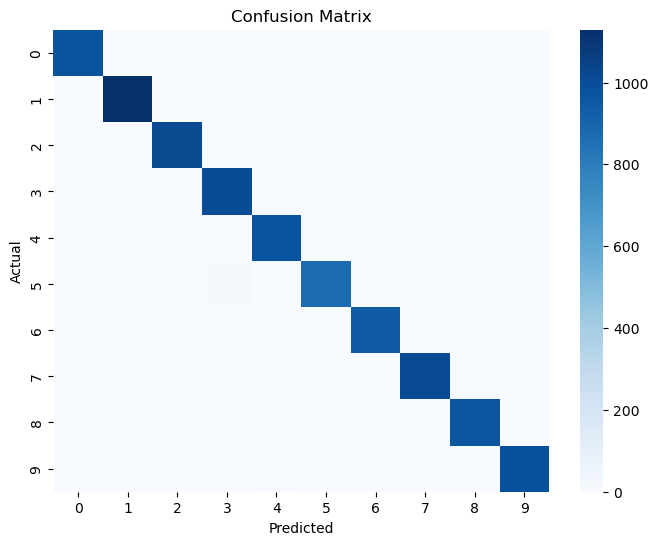

In [107]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

all_preds = []
all_labels = []

final_model.eval()

with torch.no_grad():
    for images, labels in final_test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = final_model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

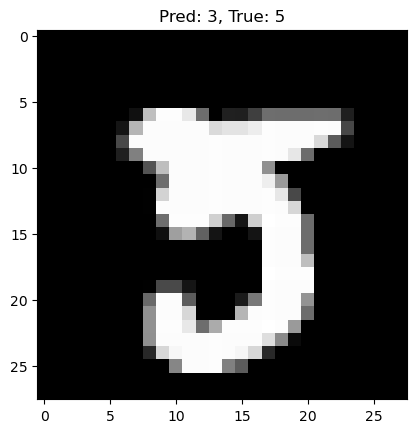

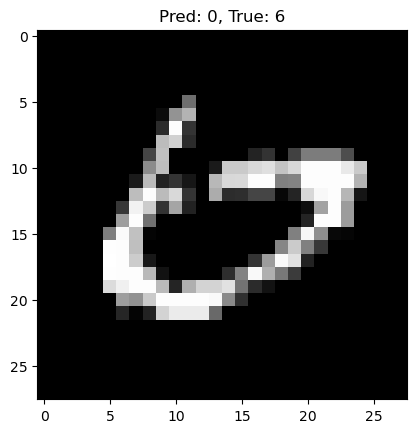

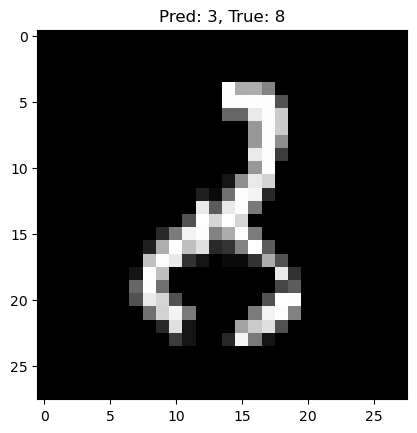

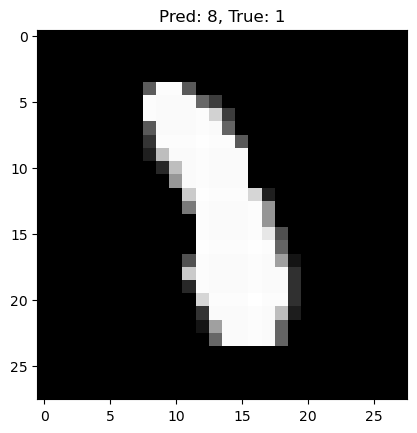

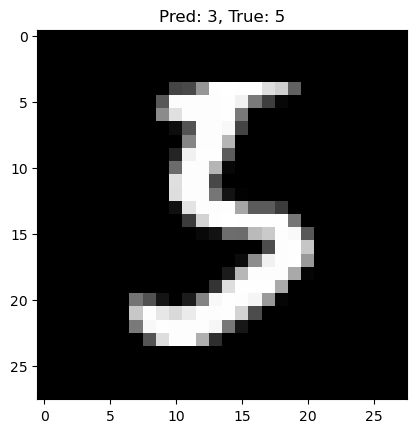

In [ ]:
#misclassified sample
count = 0

for images, labels in final_test_loader:
    images, labels = images.to(device), labels.to(device)

    outputs = final_model(images)
    _, preds = torch.max(outputs, 1)

    for i in range(len(preds)):
        if preds[i] != labels[i]:
            plt.imshow(images[i].cpu().squeeze(), cmap="gray")
            plt.title(f"Pred: {preds[i]}, True: {labels[i]}")
            plt.show()

            count += 1
            if count == 5:
                break
    if count == 5:
        break

////t-sne plot////

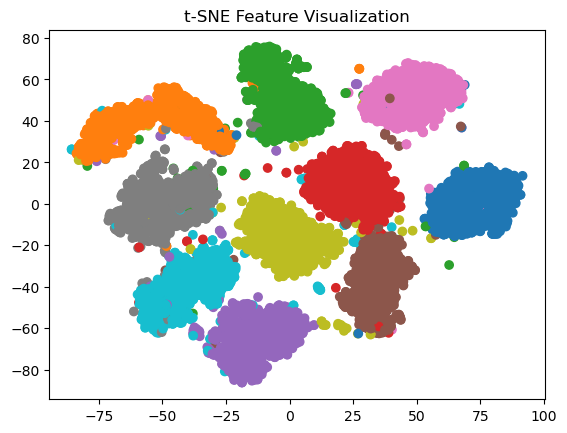

In [109]:
from sklearn.manifold import TSNE

features = []
labels_list = []

final_model.eval()

with torch.no_grad():
    for images, labels in final_test_loader:
        images = images.to(device)

        x = final_model.cnn(images)
        x = x.view(x.size(0), -1)

        features.append(x.cpu())
        labels_list.append(labels)

features = torch.cat(features).numpy()
labels_list = torch.cat(labels_list).numpy()

tsne = TSNE(n_components=2)
X = tsne.fit_transform(features)

plt.scatter(X[:,0], X[:,1], c=labels_list, cmap='tab10')
plt.title("t-SNE Feature Visualization")
plt.show()